In [1]:
import numpy as np
import matplotlib.pyplot as plt

/home/deve/myenv/lib/python3.12/site-packages/numpy/_core/getlimits.py:551: UserWarning: Signature b'\x00\xd0\xcc\xcc\xcc\xcc\xcc\xcc\xfb\xbf\x00\x00\x00\x00\x00\x00' for <class 'numpy.longdouble'> does not match any known type: falling back to type probe function.
This warnings indicates broken support for the dtype!
  machar = _get_machar(dtype)


In [2]:
#Q1
n1 = eval(input("enter a number: "))
n2 = eval(input("enter another number: "))
if n1 > n2:
    n3 = np.random.rand()
    print(n2 + int((n1 - n2)*n3))
else:
    n3 = np.random.rand()
    print(n1 + int((n2 - n1)*n3))

enter a number: 0
enter another number: 10
2


In [3]:
#Q2
total_meets = 0
false_meets = 0
true_meets = 0
for i in range(10000):
    tA = 30*np.random.rand()
    tB = 30*np.random.rand()
    if tA<tB:
        if tB-tA<5:
            true_meets+=1
            total_meets+=1
        else:
            false_meets+=1
            total_meets+=1
    else:
        if tA-tB<10:
            true_meets+=1
            total_meets+=1
        else:
            false_meets+=1
            total_meets+=1

print(f"The probability of them meeting is {true_meets/total_meets}")
print(f"The probability of them not meeting is {false_meets/total_meets}")

The probability of them meeting is 0.4281
The probability of them not meeting is 0.5719


In [4]:
#Q2
total_throws = 100000
touch = 0
d = 1
l = 1
for i in range(total_throws):
    x = d*np.random.rand()/2 #distance of center of stick from the next line
    theta = np.pi * np.random.rand() #angle its making with the x axis
    if x <= l/2*np.sin(theta):
        touch +=1

p = touch/total_throws
print(f"The probability of them touching is {p}")

The probability of them touching is 0.64231


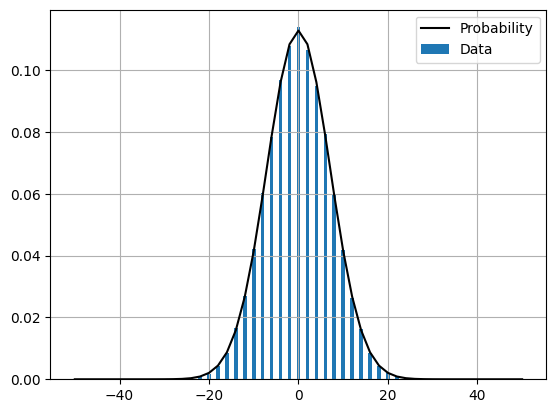

In [9]:
#Q4
def take_a_step():
    s = np.random.rand()
    if s > 0.5:
        return 1
    else:
        return -1

def prob(n, N):
    P = 2 * np.exp(- n**2/(2*N))/np.sqrt(2 * np.pi * N)
    return P

num_walkers = 100000
num_step = 50

final_positions = np.zeros(num_step+1)
for walker in range(num_walkers):
    pos = 0
    for step in range(num_step):
        pos += take_a_step()
    pos_in_array = int((pos+num_step)/2.0)
    final_positions[pos_in_array] += 1

positions = np.linspace(-num_step, num_step, num_step+1)

plt.bar(positions, final_positions/num_walkers, label = "Data")
plt.plot(positions, prob(positions, num_step), color = "k", label = "Probability")
plt.legend()
plt.grid()
#we can see that there is perfect overlap between our theoretical probabilities and observational data.

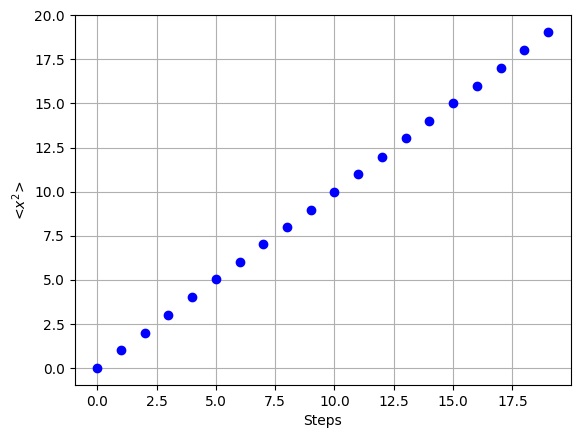

In [14]:
#Q5
def take_a_step():
    s = np.random.rand()
    if s > 0.5:
        return 1
    else:
        return -1

num_walkers = 100000
num_steps = 20

positions = np.zeros(num_walkers, dtype=int)
xaverage = np.zeros(num_steps)
for step in range(num_steps):
    xaverage[step] = sum([i**2 for i in positions])/num_walkers
    for walker in range(num_walkers):
        positions[walker] += take_a_step()
    
steps = [i for i in range(num_steps)]

plt.plot(steps,xaverage,'bo')
plt.xlabel("Steps")
plt.ylabel("<$x^2$>")
plt.grid()